## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time

from sklearn.model_selection import train_test_split
from sklearn.model_selection import PredefinedSplit
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV


from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


## Global Variables

In [42]:
seed = 42

FILENAME = "../data/train.csv"

# features = []

## Load the dataset

In [43]:
df = pd.read_csv(FILENAME, encoding='ISO-8859-1', sep=",")

In [44]:
# Printing informations
rows = df.shape[0]
cols = df.shape[1]
feature_list = df.columns.to_list()

""" print("# Righe: " + str(rows)+ " # Colonne: "+str(cols) + "\n")
for i in feature_list:
    print(i) """

' print("# Righe: " + str(rows)+ " # Colonne: "+str(cols) + "\n")\nfor i in feature_list:\n    print(i) '

In [45]:
#print(df.duplicated().sum())

#df2 = df.T.drop_duplicates().T
#print(df2.shape[1])

# Individua se esistono colonne con lo stesso nome
# Se esistono, allora se le colonne sono duplicati perfetti, droppiamo il duplicato
# Se esistono, ma nono sono perfetti duplicati, per intervenire consciamente sarebbe necessario avere maggior domain knowledge
has_duplicate_cols = len(feature_list) != len(set(feature_list))
print("Ci sono colonne con lo stesso nome?", has_duplicate_cols)

if has_duplicate_cols:
    df2 = df.T.drop_duplicates().T


df.drop_duplicates(inplace=True)
print(df.shape[0])


Ci sono colonne con lo stesso nome? False
148301


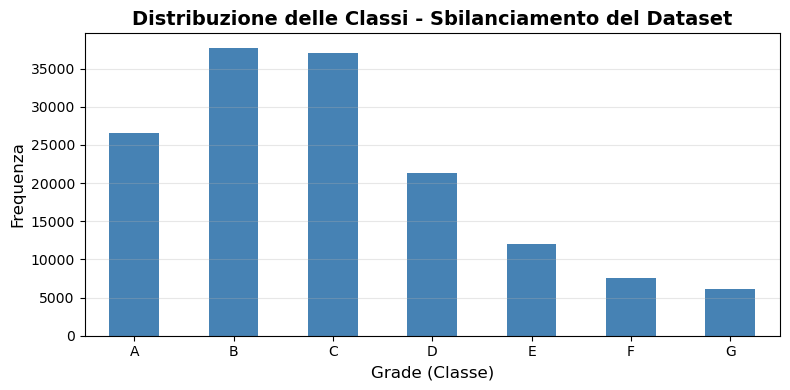


Percentuali per classe:
grade
A    17.892664
B    25.446221
C    25.003877
D    14.333686
E     8.147619
F     5.073465
G     4.102467
Name: proportion, dtype: float64


In [46]:
# Conta delle classi
grade_counts = df["grade"].value_counts().sort_index()

# Crea il bar plot
plt.figure(figsize=(8, 4))
grade_counts.plot(kind='bar', color='steelblue')
plt.title('Distribuzione delle Classi - Sbilanciamento del Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Grade (Classe)', fontsize=12)
plt.ylabel('Frequenza', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Mostra anche le percentuali
print("\nPercentuali per classe:")
print(df["grade"].value_counts(normalize=True).sort_index() * 100)


In [47]:
# Esplorazione Nan
nan = df.isna().sum() 
nan_percentages = nan / rows * 100

feature_dtypes_list = df.dtypes

# Creare un DataFrame per visualizzare in forma tabellare
nan_table = pd.DataFrame({
    'Feature': nan_percentages.index,
    'Type': feature_dtypes_list.values,
    'Nan': nan.values,
    'Percentuale NaN (%)': nan_percentages.values
}).reset_index(drop=True).sort_values(by='Percentuale NaN (%)')

print(nan_table.to_string(index=False))

                                          Feature    Type    Nan  Percentuale NaN (%)
                                            grade  object      0             0.000000
                            credit_public_records float64    881             0.594062
                        loan_contract_term_months  object    890             0.600131
                           borrower_address_state  object    895             0.603502
                         total_received_principal float64    900             0.606874
                           total_payment_received float64    903             0.608897
                        credit_delinquencies_2yrs float64    917             0.618337
                   debt_settlement_flag_indicator  object    919             0.619686
                                  tax_liens_total float64    926             0.624406
                              credit_inquiries_6m float64    927             0.625080
                  loan_payment_installments_count floa

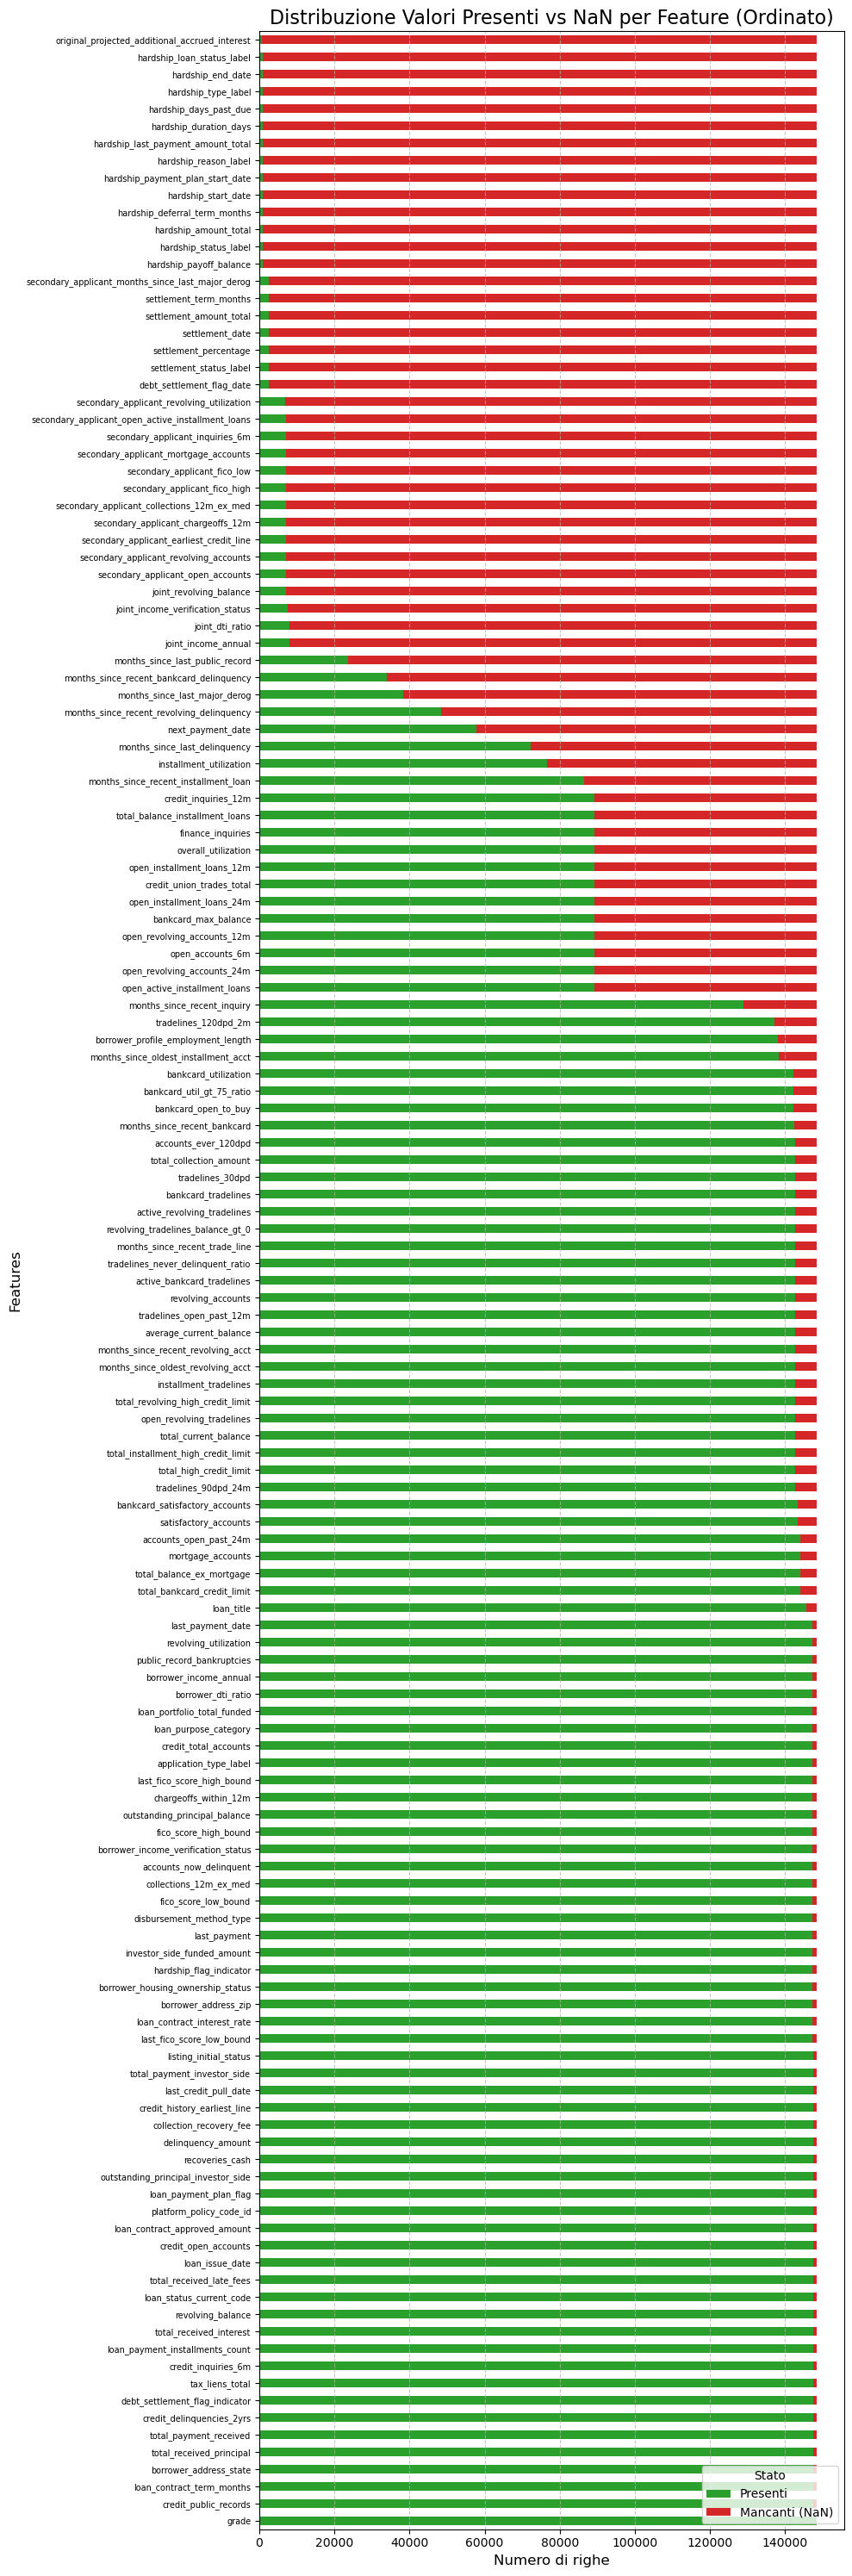

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Preparazione dei dati e calcolo percentuali
df_plot = pd.DataFrame({
    'Presenti': df.notna().sum(),
    'Mancanti (NaN)': df.isna().sum()
})
df_plot['pct_nan'] = (df_plot['Mancanti (NaN)'] / len(df)) * 100

# Ordiniamo per % di NaN crescente (così nel grafico barh i più alti appaiono in cima)
df_plot = df_plot.sort_values(by='pct_nan', ascending=True)

# 2. Creazione del grafico a barre orizzontali
ax = df_plot[['Presenti', 'Mancanti (NaN)']].plot(
    kind='barh', 
    stacked=True, 
    color=['#2ca02c', '#d62728'], 
    figsize=(10, 30) # Altezza aumentata per leggere tutte le 145 feature
)

# 3. Formattazione
plt.title('Distribuzione Valori Presenti vs NaN per Feature (Ordinato)', fontsize=16)
plt.ylabel('Features', fontsize=12)
plt.xlabel('Numero di righe', fontsize=12)

# Label delle feature rimpicciolite
plt.yticks(fontsize=7) 

plt.legend(loc='lower right', title='Stato')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('missing_values_horizontal_sorted.png')
plt.show()

In [49]:
# Splitting labels

X = df.drop(columns=["grade"])
y = df["grade"]


print(X.shape)
print(y.shape)

(148301, 144)
(148301,)


In [50]:
feature_dtypes_list = df.dtypes
""" for i,j in feature_dtypes_list.items():
    print(i, j)
 """

print(feature_dtypes_list.unique())

# Creare un DataFrame per visualizzare in forma tabellare
feature_dtypes_table = pd.DataFrame({
    'Feature': feature_dtypes_list.index,
    'Type': feature_dtypes_list.values,
    'Example first row': df.iloc[0]
    
}).reset_index(drop=True).sort_values(by='Type')

print(feature_dtypes_table.to_string(index=False))

[dtype('float64') dtype('O')]
                                          Feature    Type       Example first row
                    loan_contract_approved_amount float64                 12000.0
                            satisfactory_accounts float64                     7.0
                revolving_tradelines_balance_gt_0 float64                5.054335
                               revolving_accounts float64                     9.0
                        open_revolving_tradelines float64                     6.0
                           installment_tradelines float64                     2.0
                              bankcard_tradelines float64                6.277382
                   bankcard_satisfactory_accounts float64                5.503904
                      active_revolving_tradelines float64                     5.0
                       active_bankcard_tradelines float64                     5.0
                             accounts_ever_120dpd float64           

In [51]:
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
for i in categorical_features:
    print(X[i].value_counts().sort_index())
    print("\n")

# extract digits and cast to float
X['loan_contract_term_months'] = X['loan_contract_term_months'].str.extract(r'(\d+)').astype(float)
print(X['loan_contract_term_months'].value_counts().sort_index())

X['borrower_profile_employment_length'] = X['borrower_profile_employment_length'].str.replace(r'\+? years?', '', regex=True)
""" print(X['borrower_profile_employment_length'].value_counts().sort_index())
print("\n") """

mappings = { '< 1': 0}
X['borrower_profile_employment_length'] = X['borrower_profile_employment_length'].replace(mappings).astype(float)
print(X['borrower_profile_employment_length'].value_counts().sort_index())

# drop non significant columns perche abbiamo gia un grouping di loan_purpose_category
X.drop('loan_title', axis=1, inplace=True)

# Remove dropped columns
categorical_features.remove('loan_title')

loan_contract_term_months
36 months    97786
60 months    49625
Name: count, dtype: int64


borrower_profile_employment_length
1 year        9586
10+ years    48504
2 years      13298
3 years      11703
4 years       8980
5 years       9147
6 years       6693
7 years       6176
8 years       6103
9 years       5335
< 1 year     12420
Name: count, dtype: int64


borrower_housing_ownership_status
any            66
mortgage    71697
none            3
other          16
own         16621
rent        58939
Name: count, dtype: int64


borrower_income_verification_status
not verified       45206
source verified    57451
verified           44664
Name: count, dtype: int64


loan_issue_date
apr-2008      24
apr-2009      17
apr-2010      50
apr-2011      99
apr-2012     192
            ... 
sep-2014     779
sep-2015    1903
sep-2016    1864
sep-2017    2779
sep-2018    2461
Name: count, Length: 138, dtype: int64


loan_status_current_code
charged off                                            207

In [ ]:
import re

# Definizione della regex: 3 lettere, un trattino, e 4 cifre
# Esempio: "jan-2017", "Aug-1995"
date_regex = re.compile(r'^[a-z]{3}-\d{4}$', re.IGNORECASE)

# Identificazione delle colonne che contengono stringhe con questo pattern
# Controlliamo i valori non nulli per determinare se la colonna è di tipo data mmm-yyyy
date_cols = [
    col for col in df.columns 
    if not df[col].dropna().empty and 
    df[col].dropna().head(5).apply(lambda x: bool(date_regex.match(str(x)))).all()
]

# Calcolo dei NaN solo per le colonne identificate
nan_dates = df[date_cols].isna().sum()
nan_dates_percentages = (nan_dates / rows) * 100

# Creazione della tabella dedicata alle date
nan_date_table = pd.DataFrame({
    'Feature (Date mmm-yyyy)': nan_dates.index,
    'Nan': nan_dates.values,
    'Percentuale NaN (%)': nan_dates_percentages.values
}).reset_index(drop=True).sort_values(by='Percentuale NaN (%)', ascending=False)

print("Analisi valori mancanti per colonne temporali (mmm-yyyy):")
print(nan_date_table.to_string(index=False))

Analisi valori mancanti per colonne temporali (mmm-yyyy):
                 Feature (Date mmm-yyyy)    Nan  Percentuale NaN (%)
                       hardship_end_date 147458            99.431561
                     hardship_start_date 147455            99.429539
        hardship_payment_plan_start_date 147455            99.429539
                         settlement_date 145750            98.279850
               debt_settlement_flag_date 145748            98.278501
secondary_applicant_earliest_credit_line 141225            95.228623
                       next_payment_date  90439            60.983405
                       last_payment_date   1132             0.763312
                   last_credit_pull_date    953             0.642612
            credit_history_earliest_line    952             0.641938
                         loan_issue_date    938             0.632497


In [ ]:
numerical_features = X.select_dtypes(include=['float', 'int']).columns.tolist()
nan = df[numerical_features].isna().sum()
nan_percentages = (nan / rows) * 100


# Creazione della tabella dedicata alle date
nan_date_table = pd.DataFrame({
    'Feature': nan.index,
    'Nan': nan.values,
    'Percentuale NaN (%)': nan_percentages.values
}).reset_index(drop=True).sort_values(by='Percentuale NaN (%)', ascending=False)

print("Analisi valori mancanti per colonne numeriche:")
print(nan_date_table.to_string(index=False))

In [ ]:
# 1. DROP: Data Leakage (Future Information)
leakage_cols = [
    # hardship leakage
    'hardship_duration_days', 'hardship_last_payment_amount_total', 
    'hardship_days_past_due', 'hardship_deferral_term_months', 
    'hardship_amount_total', 'hardship_payoff_balance', 
    # settlement leakage
    'settlement_term_months', 'settlement_amount_total', 'settlement_percentage',
    # pure leakage variables
    'total_payment_received', 'total_received_principal', 'recoveries_cash',
    'collection_recovery_fee', 'last_payment', 'outstanding_principal_balance',
    'total_received_interest', 'total_received_late_fees',
    # to decide
    'original_projected_additional_accrued_interest',
]

# 2. DROP: Secondary/Joint Applicant info (>95% missing)
secondary_cols = [
    'secondary_applicant_months_since_last_major_derog',
    'secondary_applicant_revolving_utilization',
    'secondary_applicant_open_active_installment_loans',
    'secondary_applicant_inquiries_6m',
    'secondary_applicant_mortgage_accounts',
    'secondary_applicant_fico_low',
    'secondary_applicant_fico_high',
    'secondary_applicant_collections_12m_ex_med',
    'secondary_applicant_chargeoffs_12m',
    'secondary_applicant_revolving_accounts',
    'secondary_applicant_open_accounts',
    'joint_revolving_balance',
    'joint_dti_ratio',
    'joint_income_annual'
]

# Execute Drop
cols_to_drop = leakage_cols + secondary_cols
# Filter to ensure we only drop columns that actually exist in your dataframe
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

df_clean = df.drop(columns=cols_to_drop)

# 3. KEEP & FILL: "Months Since" columns (NaN = Never happened)
# We fill with a large number (e.g., 1000 months) to signify "very long time ago / never"
structural_cols = [
    'months_since_last_public_record', 
    'months_since_recent_bankcard_delinquency',
    'months_since_last_major_derog', 
    'months_since_recent_revolving_delinquency',
    'months_since_last_delinquency'
]

for col in months_since_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(1000) # TODO investigate if 1000 is appropriate

print(f"Dropped {len(cols_to_drop)} columns.")
print(f"Remaining columns: {df_clean.shape[1]}")

In [ ]:
# to flag: hardship e settlement
# to calculate: loan_issue_date, credit_history_earliest_line
# ??? : last_payment_date, last_credit_pull_date
# to drop: secondary_applicant_earliest_credit_line, next_payment_date

# flag
# Crea un indicatore: 1 se ha avuto problemi/accordi, 0 altrimenti
X['has_settlement_plan'] = X['settlement_date'].notna().astype(int)
X['has_hardship_plan'] = X['hardship_start_date'].notna().astype(int)

X['loan_issue_date'] = pd.to_datetime(X['loan_issue_date'], format='%b-%Y')

X['issue_month'] = X['loan_issue_date'].dt.month

# cyclical Encoding
X['issue_month_sin'] = np.sin(2 * np.pi * X['issue_month'] / 12)
X['issue_month_cos'] = np.cos(2 * np.pi * X['issue_month'] / 12)

# calculate
X['credit_history_earliest_line'] = pd.to_datetime(X['credit_history_earliest_line'], format='%b-%Y')

X['months_since_earliest_cr_line'] = (
    (X['loan_issue_date'].dt.year - X['credit_history_earliest_line'].dt.year) * 12 + 
    (X['loan_issue_date'].dt.month - X['credit_history_earliest_line'].dt.month)
)
 
to_drop = ['hardship_end_date',
          'hardship_start_date', 
          'hardship_payment_plan_start_date', 
          'settlement_date', 
          'debt_settlement_flag_date', 
          'secondary_applicant_earliest_credit_line', 
          'secondary_applicant_earliest_credit_line', 
          'next_payment_date',
          'last_payment_date',
          'issue_month', 
          'loan_issue_date']

X = X.drop(columns=to_drop)
print(f"Columns remaining: {X.shape[1]}")

Columns remaining: 139


In [ ]:
# Split train test: 0.25
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, stratify=y, random_state=seed)

In [ ]:
numerical_features = X.select_dtypes(include=['float', 'int']).columns.tolist()
nan = df[numerical_features].isna().sum()
nan_percentages = (nan / rows) * 100


# Creazione della tabella dedicata alle date
nan_date_table = pd.DataFrame({
    'Feature': nan.index,
    'Nan': nan.values,
    'Percentuale NaN (%)': nan_percentages.values
}).reset_index(drop=True).sort_values(by='Percentuale NaN (%)', ascending=False)

print("Analisi valori mancanti per colonne numeriche:")
print(nan_date_table.to_string(index=False))

impute_median_cols = [
    'borrower_dti_ratio',
    'borrower_income_annual',
    'revolving_utilization',
    'total_revolving_high_credit_limit',
    'avg_cur_bal',
    'bc_open_to_buy',
    'bc_util'
]

# Setup the imputer
imputer = SimpleImputer(strategy='median')

# Fit on TRAIN only (Learn the medians)
imputer.fit(X_train[numerical_missing_cols])

# Transform BOTH (Fill NaNs)
X_train[numerical_missing_cols] = imputer.transform(X_train[numerical_missing_cols])
X_val[numerical_missing_cols] = imputer.transform(X_val[numerical_missing_cols])

print("Imputation sequence complete.")

In [14]:
import re

# Regex per identificare il pattern mmm-yyyy
date_regex = re.compile(r'^[a-z]{3}-\d{4}$', re.IGNORECASE)

# Identificazione colonne temporali
date_cols = [
    col for col in df.columns 
    if not df[col].dropna().empty and 
    df[col].dropna().head(10).apply(lambda x: bool(date_regex.match(str(x)))).all()
]

# Estrazione statistiche e distribuzione label per righe non-NaN
stats = []
grade_order = sorted(df['grade'].unique())

for col in date_cols:
    non_nan_df = df[df[col].notna()]
    total_non_nan = len(non_nan_df)
    
    # Conteggio grade per le righe dove la data è presente
    grade_counts = non_nan_df['grade'].value_counts().to_dict()
    
    entry = {
        'Feature': col,
        'Nan': df[col].isna().sum(),
        'Nan %': (df[col].isna().sum() / len(df)) * 100,
        'Righe Non-NaN': total_non_nan
    }
    
    # Aggiungiamo i conteggi per ogni grado (A, B, C...)
    for g in grade_order:
        entry[f'Grade {g}'] = grade_counts.get(g, 0)
        
    stats.append(entry)

# Creazione DataFrame finale
summary_df = pd.DataFrame(stats).sort_values(by='Nan %', ascending=False)
print(summary_df.to_string(index=False))

                                 Feature    Nan     Nan %  Righe Non-NaN  Grade A  Grade B  Grade C  Grade D  Grade E  Grade F  Grade G
                       hardship_end_date 147458 99.431561            843       44      146      227      169      101       79       77
                     hardship_start_date 147455 99.429539            846       43      146      228      168      102       80       79
        hardship_payment_plan_start_date 147455 99.429539            846       44      146      226      170      102       79       79
                         settlement_date 145750 98.279850           2551      152      393      630      494      383      261      238
               debt_settlement_flag_date 145748 98.278501           2553      154      401      625      493      383      260      237
secondary_applicant_earliest_credit_line 141225 95.228623           7076     1354     1732     1856     1026      500      280      328
                       next_payment_date  90439 

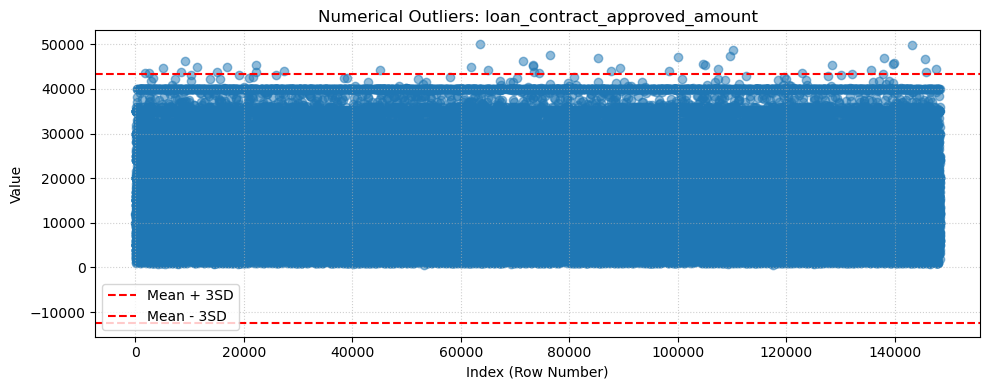

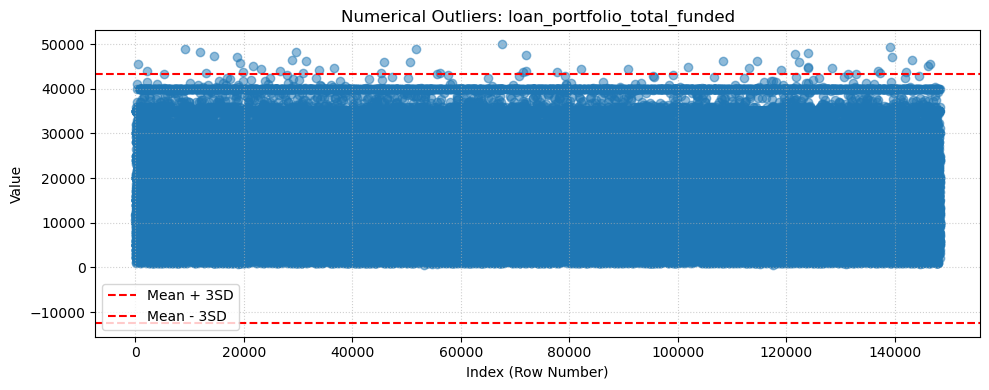

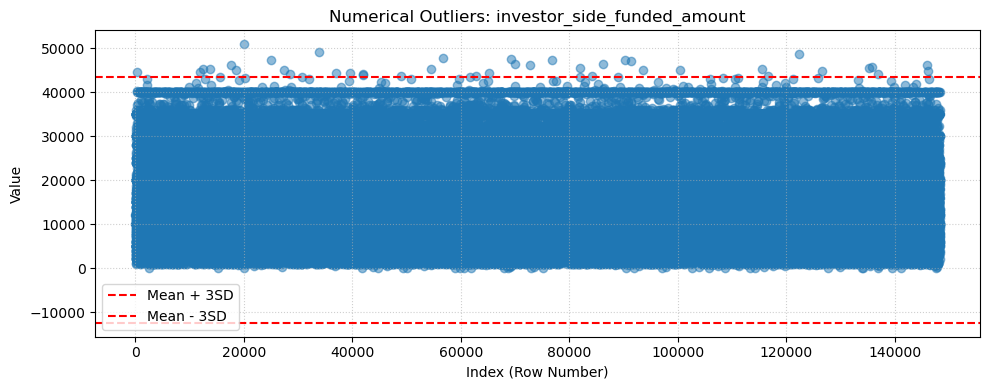

In [ ]:
numerical_cols = X.select_dtypes(include=['float', 'int']).columns
#categorical_cols = X.select_dtypes(include=['object', 'category']).columns

# 2. Loop and Plot
for col in numerical_cols:
    plt.figure(figsize=(10, 4))
    
    if col in numerical_cols:
        # --- NUMERICAL: SCATTER PLOT ---
        # Plot Index vs Value. Outliers will appear vertically distant from the main cloud.
        plt.scatter(x=X.index, y=X[col], alpha=0.5)
        
        # Optional: Add lines for Mean +/- 3 Std Dev to help identify extreme values
        mean = X[col].mean()
        std = X[col].std()
        plt.axhline(mean + 3*std, color='r', linestyle='--', label='Mean + 3SD')
        plt.axhline(mean - 3*std, color='r', linestyle='--', label='Mean - 3SD')
        plt.legend()
        plt.title(f"Numerical Outliers: {col}")
        plt.ylabel("Value")
        plt.xlabel("Index (Row Number)")
        
    else:
        # --- CATEGORICAL: BAR CHART ---
        # Outliers here are 'Rare Categories'. We plot frequency.
        # If a bar is extremely short (e.g., count=1), it's a rare category.
        X_train[col].value_counts().plot(kind='bar', color='orange')
        plt.title(f"Categorical Frequencies: {col}")
        plt.ylabel("Count")
        plt.xlabel("Category") 
        
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()
 

In [ ]:
def analyze_and_plot_outliers(df):
    # 1. Select only numerical columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    if len(numeric_cols) == 0:
        print("No numerical columns found!")
        return

    # 2. Prepare the figure
    # Create one subplot per column
    fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(10, 4 * len(numeric_cols)))
    
    # Handle case if there's only one numerical column (axes is not a list)
    if len(numeric_cols) == 1:
        axes = [axes]

    print(f"{'Column':<20} | {'Lower Cutoff':<15} | {'Upper Cutoff':<15}")
    print("-" * 55)

    for i, col in enumerate(numeric_cols):
        ax = axes[i]
        
        # 3. Calculate IQR stats
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        print(f"{col:<20} | {lower_bound:<15.2f} | {upper_bound:<15.2f}")

        # 4. Plot Boxplot
        # vert=False makes it horizontal, which is often easier to read
        ax.boxplot(df[col].dropna(), vert=False, patch_artist=True, 
                   boxprops=dict(facecolor='lightblue', color='blue'),
                   medianprops=dict(color='red', linewidth=2))
        
        # 5. Add Cutoff Lines
        ax.axvline(lower_bound, color='orange', linestyle='--', linewidth=1.5, label='Lower Limit')
        ax.axvline(upper_bound, color='orange', linestyle='--', linewidth=1.5, label='Upper Limit')
        
        ax.set_title(f"Distribution & Cutoffs: {col}")
        ax.set_xlabel("Value")
        ax.legend()
        ax.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

# Run it on your training data
analyze_and_plot_outliers(X)

In [ ]:

def calculate_outlier_percentage(df):
    # Select numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    # Create a list to store results
    results = []

    for col in numeric_cols:
        # 1. Calculate IQR
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # 2. Count Outliers
        # An outlier is anything strictly less than lower OR strictly greater than upper
        n_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
        
        # 3. Calculate Percentage
        total_rows = df.shape[0]
        percentage = (n_outliers / total_rows) * 100
        
        results.append({
            "Column": col,
            "Lower Cutoff": round(lower_bound, 2),
            "Upper Cutoff": round(upper_bound, 2),
            "Outliers Count": n_outliers,
            "Outliers %": round(percentage, 2)
        })

    # Convert to DataFrame for a nice table display
    results_df = pd.DataFrame(results)
    
    # Sort by percentage descending to see the "worst" columns first
    results_df = results_df.sort_values(by="Outliers %", ascending=False)
    
    return results_df

# Run and display
outlier_stats = calculate_outlier_percentage(X)
with pd.option_context('display.max_rows', None):
    print(outlier_stats)

In [ ]:
""" 
# 1. Selezione delle sole colonne numeriche 
# (Assicurati di aver già rimosso o trasformato le date e le categoriche)
X_train_numeric = X_train.select_dtypes(include=[np.number])
X_val_numeric = X_val.select_dtypes(include=[np.number])

# 2. Imputazione dei valori mancanti (la PCA non ammette NaN)
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train_numeric)
X_val_imputed = imputer.transform(X_val_numeric)

# 3. Standardizzazione (Fondamentale per la PCA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)

# 4. Applicazione PCA
# Usiamo n_components=0.95 per mantenere il 95% della varianza totale
pca = PCA(n_components=0.90)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)

print(f"Dimensioni originali: {X_train_scaled.shape[1]}")
print(f"Dimensioni dopo PCA (90% varianza): {X_train_pca.shape[1]}")

# --- Visualizzazione della Varianza Spiegata ---
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Numero di Componenti')
plt.ylabel('Varianza Spiegata Cumulativa')
plt.title('Analisi della Varianza per PCA')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.grid()
plt.show() """

In [ ]:
""" # 1. Recupera i nomi delle colonne originali usate per la PCA
# (Assumendo che X_train_scaled sia il risultato dello StandardScaler)
feature_names = X_train.select_dtypes(include=[np.number]).columns

# 2. Crea un DataFrame con l'importanza relativa (Varianza Spiegata)
pca_importance = pd.DataFrame({
    'Componente': [f'PCA_{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    'Varianza Spiegata': pca.explained_variance_ratio_,
    'Varianza Cumulativa': np.cumsum(pca.explained_variance_ratio_)
})

print("--- Importanza Relativa dei Componenti PCA ---")
print(pca_importance.to_string(index=False))

# 3. Analisi dei "Loadings" (quali feature pesano di più sui componenti)
# Prendiamo ad esempio il primo componente (PCA_1)
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PCA_{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    index=feature_names
)

print("\n--- Top 5 Feature originali per importanza in PCA_1 ---")
# Usiamo il valore assoluto perché un peso molto negativo è importante quanto uno positivo
top_features_pca1 = loadings['PCA_2'].abs().sort_values(ascending=False)
print(top_features_pca1) """

In [ ]:

# Create encoder with handle_unknown to deal with unseen categories
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit on training data only
ohe.fit(X_train[categorical_features])

# Transform both sets
X_train_encoded = ohe.transform(X_train[categorical_features])
X_val_encoded = ohe.transform(X_val[categorical_features])

# Get feature names for the encoded columns
encoded_feature_names = ohe.get_feature_names_out(categorical_features)

# Create DataFrames with the encoded features
X_train_ohe = pd.DataFrame(X_train_encoded, 
                           columns=encoded_feature_names,
                           index=X_train.index)
X_val_ohe = pd.DataFrame(X_val_encoded, 
                         columns=encoded_feature_names,
                         index=X_val.index)

# Drop original categorical columns and concatenate encoded ones
X_train = X_train.drop(columns=categorical_features).join(X_train_ohe)
X_val = X_val.drop(columns=categorical_features).join(X_val_ohe)


le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.fit(y_val)


print(X_train.head())

In [ ]:


# 1. Trasforma X_train_pca in DataFrame
# Usiamo l'indice di X_train_ohe per garantire l'allineamento perfetto delle righe
X_train_pca_df = pd.DataFrame(
    X_train_pca, 
    columns=[f'PCA_{i+1}' for i in range(X_train_pca.shape[1])],
    index=X_train_ohe.index
)

# 2. Unione (Concatenazione orizzontale) per il Training Set
X_train_final = pd.concat([X_train_ohe, X_train_pca_df], axis=1)

# 3. Trasforma X_val_pca in DataFrame
X_val_pca_df = pd.DataFrame(
    X_val_pca, 
    columns=[f'PCA_{i+1}' for i in range(X_val_pca.shape[1])],
    index=X_val_ohe.index
)

# 4. Unione per il Validation Set
X_val_final = pd.concat([X_val_ohe, X_val_pca_df], axis=1)

print(f"Nuova dimensione Training Set: {X_train_final.shape}")
print(f"Nuova dimensione Validation Set: {X_val_final.shape}")

In [ ]:
""" ## TODO: quale encoder e' meglio usare?
# ricerca: categorical feature transform in ml
# https://www.geeksforgeeks.org/machine-learning/encoding-categorical-data-in-sklearn/

for col in X_train[categorical_features].columns:    
    le = LabelEncoding(sparse_output=False)
    values_train = X_train[col].dropna().values 
    values_val = X_val[col].dropna().values
    
    values = np.union1d(values_train, values_val)
    
    le = le.fit(values)
    X_train[col] = le.transform(X_train[col])
    X_val[col] = le.transform(X_val[col])

print(X_train.head())


# y encoding
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.fit(y_val) """

# TODO
- VERIFICA OUTLIER E RIPARAZIONE
- FILL MISSING VALUES
- DATA BALANCING (Undersampling to 20 k?)
- SCALING
- PCA ?? 

## Define the scalers to be used

In [ ]:
# Scalers to test
scalers = {
    "MinMaxScaler": MinMaxScaler(),
    "StandardScaler": StandardScaler()
}

## Apply Random Forests with hyperparameters tuning

In [ ]:
param_grid_rf = {
    'clf__n_estimators': [10, 100, 1000],
    'clf__max_features': [None, 'sqrt', 'log2'],
    'clf__criterion': ['gini', 'entropy', 'log_loss'],
    'clf__max_depth': [None, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
}

# Grid Search with Pipeline
best_score = 0

for scaler_name, scaler in scalers.items():

        pipeline = Pipeline([
            #("scaler", scaler),
            ("clf", RandomForestClassifier(random_state=seed))
        ])

        # Perform Grid Search

        if grid.best_score_ > best_score:
            best_score = grid.best_score_
            file = open("rf_scaler.save","wb")
            pickle.dump(grid.best_estimator_['scaler'], file)
            file.close()
            file = open("rf.save","wb")
            pickle.dump(grid.best_estimator_['clf'], file)
            file.close()

## Apply Logistic Regression

In [ ]:
# train/val split 
indices = np.arange(X.shape[0])
train_idx, val_idx = train_test_split(indices, test_size=0.1, stratify=y, random_state=seed)

X_val_raw = X[val_idx,:]
y_val = y[val_idx]
X_train_raw = X[train_idx,:]
y_train = y[train_idx]


best_score = 0
for name, scaler in scalers.items():
    # scale data
    

    # train model
    
    print("Performance:",score)

    if score > best_score:
        best_score = score
        file_scaler = open("lr_scaler.save","wb")
        pickle.dump(scaler, file_scaler)
        file_clf = open("lr.save","wb")
        pickle.dump(clf, file_clf)
        file_clf.close()



## Apply Support Vector Classifier with hyperparameters tuning

In [ ]:
# SVC param grid
param_grid_svc = {'clf__C': [0.1, 1, 10, 100, 1000],
              'clf__kernel': ["linear", "poly", "rbf"]}

# Grid Search with Pipeline
best_score = 0
for scaler_name, scaler in scalers.items():

        pipeline = Pipeline([
            ("scaler", scaler),
            ("clf", SVC(random_state=seed))
        ])

        # Perform Grid Search
        

        if grid.best_score_ > best_score:
            best_score = grid.best_score_
            file = open("svc_scaler.save","wb")
            pickle.dump(grid.best_estimator_['scaler'], file)
            file.close()
            file = open("svc.save","wb")
            pickle.dump(grid.best_estimator_['clf'], file)
            file.close()
